# Phase 4 — Seasonality Analysis: Does incident rate vary by month?

**Research question:** Is the per-visit incident rate (incidents / tasks) stable
across the six study months (Jan–Jun 2024), or does it vary in a way that would
justify month-sensitive dispatch scheduling?

**Analytical approach:**
1. Compute per-month descriptive statistics (mean, median, 95 % bootstrap CI).
2. Kruskal-Wallis H-test — non-parametric omnibus test for any distributional
   difference across months. Appropriate because incident_rate is right-skewed
   and zero-inflated; ANOVA normality assumptions would not hold.
3. Dunn's pairwise post-hoc with Bonferroni correction — only if KW is
   significant (p < 0.05). Tests which specific month pairs differ.

Missing-data assumption: `missing_is_zero` (2 396 rows across 6 months).

**Coverage caveat:** The number of (location, month) rows with a recorded
technician visit ramps from 302 in January to 482 in June — a 60 % increase
likely reflecting operational data-recording ramp-up rather than a true policy
change. Because the analysis operates on *rate* (incidents / tasks), not raw
counts, this does not bias the estimated rates directly. However, January's
smaller sample means its CI is wider and its mean is less stable. Interpret
January results with extra caution.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("src").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import load_raw, build_panel, apply_missing_data_assumption
from seasonality_analysis import monthly_rate_summary, kruskal_seasonality, dunns_posthoc
from plots import setup_style, plot_monthly_rate, plot_monthly_rate_comparison

setup_style()
DATA_PATH = Path("data/session_stats.xlsx")

sessions, tasks, incidents = load_raw(DATA_PATH)
panel = build_panel(sessions, tasks, incidents)
panel_zero = apply_missing_data_assumption(panel, "missing_is_zero")
panel_zero = panel_zero.copy()
panel_zero["month_str"] = panel_zero["month"].dt.to_period("M").astype(str)
print(f"Panel rows: {len(panel_zero):,}  |  Months: {panel_zero['month_str'].nunique()}")


Panel rows: 2,396  |  Months: 6


## 1. Monthly rate summary

Each row is one calendar month. The 95 % CI is the percentile bootstrap
interval on the mean (1 000 resamples, seed = 42).

In [2]:
summary = monthly_rate_summary(panel_zero)
display(summary.style
    .format({
        "n_observations": "{:.0f}",
        "mean_rate":      "{:.4f}",
        "median_rate":    "{:.4f}",
        "std":            "{:.4f}",
        "ci_low":         "{:.4f}",
        "ci_high":        "{:.4f}",
    })
    .set_caption("Table 1. Per-month incident rate summary (missing_is_zero assumption)")
)


,month,n_observations,mean_rate,median_rate,std,ci_low,ci_high
0,2024-01,302,0.0818,0.0000,0.1776,0.0627,0.1033
1,2024-02,329,0.0930,0.0000,0.1672,0.0751,0.1106
2,2024-03,433,0.1291,0.0500,0.3420,0.1012,0.1662
3,2024-04,408,0.1065,0.0000,0.2006,0.0879,0.1258
4,2024-05,442,0.1063,0.0000,0.2097,0.0867,0.1248
5,2024-06,482,0.0870,0.0000,0.2354,0.0680,0.1083


**Commentary:** The mean rate ranges from roughly 0.08 to 0.13 across months.
March's standard deviation (0.342) is nearly double the next-highest month,
flagging a potential tail effect that we investigate in Section 4.

## 2. Visualization

Mean incident rate by month with 95 % bootstrap CI band. The shaded region shows
the uncertainty on the mean; the line connects months chronologically.

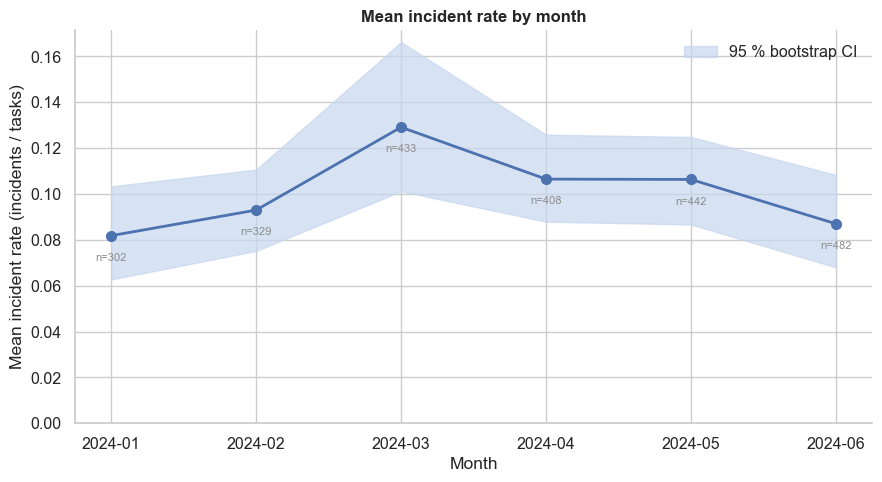

Saved: figures/seasonality.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_monthly_rate(summary, ax=ax)

for _, row in summary.iterrows():
    ax.annotate(
        f"n={row['n_observations']}",
        xy=(row["month"], row["mean_rate"]),
        xytext=(0, -18), textcoords="offset points",
        ha="center", fontsize=8, color="#8C8C8C",
    )

fig.tight_layout()
fig.savefig("figures/seasonality.png")
plt.show()
print("Saved: figures/seasonality.png")


## 3. Statistical tests

### 3a. Kruskal-Wallis H-test

Tests whether the six monthly distributions of incident_rate are identical.
H0: all six months come from the same distribution.

In [4]:
kw = kruskal_seasonality(panel_zero)
print(f"Kruskal-Wallis H = {kw['H_statistic']:.4f},  p = {kw['p_value']:.4f}")
print()
print("n per month:")
for m, n in kw["n_per_month"].items():
    print(f"  {m}: {n:,}")


Kruskal-Wallis H = 23.0749,  p = 0.0003

n per month:
  2024-01: 302
  2024-02: 329
  2024-03: 433
  2024-04: 408
  2024-05: 442
  2024-06: 482


### 3b. Dunn's pairwise post-hoc (Bonferroni-corrected)

Runs only if Kruskal-Wallis is significant (p < 0.05). Each cell shows the
Bonferroni-adjusted p-value for that pair of months. Values below 0.05 indicate
a significant pairwise difference after correction for 15 comparisons.

In [5]:
dunn = dunns_posthoc(panel_zero)
if dunn is not None:
    display(dunn.style
        .format("{:.4f}")
        .background_gradient(cmap="RdYlGn_r", vmin=0, vmax=1)
        .set_caption("Table 2. Dunn's post-hoc adjusted p-values (Bonferroni)")
    )


,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06
2024-01,1.0000,0.4557,0.0003,0.4257,0.6406,1.0000
2024-02,0.4557,1.0000,0.6815,1.0000,1.0000,1.0000
2024-03,0.0003,0.6815,1.0000,0.4068,0.1981,0.0017
2024-04,0.4257,1.0000,0.4068,1.0000,1.0000,1.0000
2024-05,0.6406,1.0000,0.1981,1.0000,1.0000,1.0000
2024-06,1.0000,1.0000,0.0017,1.0000,1.0000,1.0000


## 4. Tail sensitivity check

March's standard deviation (0.342) is nearly double the next-highest month,
raising the question of whether the elevation reflects a network-wide spring
effect or a concentrated tail of high-incident stations. We test this by
comparing trimmed and untrimmed monthly means.

In [6]:
months_order = sorted(panel_zero["month_str"].unique())

tail_counts = (
    panel_zero.groupby("month_str")["incident_rate"]
    .apply(lambda s: (s > 0.5).sum())
)

rows = []
for m in months_order:
    grp = panel_zero[panel_zero["month_str"] == m]["incident_rate"]
    p95 = np.percentile(grp, 95)
    untrimmed = grp.mean()
    trimmed = grp[grp <= p95].mean()
    n_tail = int(tail_counts.get(m, 0))
    rows.append({
        "month": m,
        "n": len(grp),
        "n_rate_gt_0.5": n_tail,
        "pct_tail": round(n_tail / len(grp) * 100, 1),
        "untrimmed_mean": round(untrimmed, 4),
        "trimmed_mean_p95": round(trimmed, 4),
        "drop": round(trimmed - untrimmed, 4),
    })

tail_df = pd.DataFrame(rows)
display(tail_df.style
    .format({
        "n": "{:.0f}",
        "n_rate_gt_0.5": "{:.0f}",
        "pct_tail": "{:.1f}%",
        "untrimmed_mean": "{:.4f}",
        "trimmed_mean_p95": "{:.4f}",
        "drop": "{:+.4f}",
    })
    .highlight_max(subset=["untrimmed_mean", "trimmed_mean_p95"], color="#fdd")
    .set_caption("Table 3. Untrimmed vs 5%-trimmed monthly means")
)

mar_trim = tail_df.loc[tail_df["month"] == "2024-03", "trimmed_mean_p95"].values[0]
jan_full = tail_df.loc[tail_df["month"] == "2024-01", "untrimmed_mean"].values[0]
jun_full = tail_df.loc[tail_df["month"] == "2024-06", "untrimmed_mean"].values[0]
print(f"March trimmed mean: {mar_trim:.4f}  |  Jan full mean: {jan_full:.4f}  |  Jun full mean: {jun_full:.4f}")


,month,n,n_rate_gt_0.5,pct_tail,untrimmed_mean,trimmed_mean_p95,drop
0,2024-01,302,10,3.3%,0.0818,0.0469,-0.0349
1,2024-02,329,7,2.1%,0.0930,0.0637,-0.0293
2,2024-03,433,19,4.4%,0.1291,0.0847,-0.0444
3,2024-04,408,15,3.7%,0.1065,0.0692,-0.0373
4,2024-05,442,15,3.4%,0.1063,0.0694,-0.0369
5,2024-06,482,11,2.3%,0.0870,0.0520,-0.0349


March trimmed mean: 0.0847  |  Jan full mean: 0.0818  |  Jun full mean: 0.0870


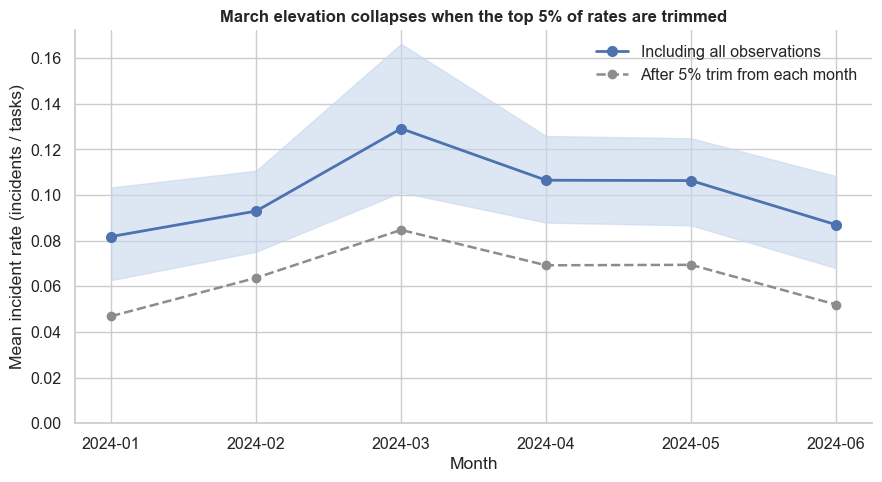

Saved: figures/seasonality_trimming_comparison.png


In [7]:
# Build the two DataFrames the helper expects.
untrimmed_df = summary.rename(columns={"mean_rate": "untrimmed_mean"})
trimmed_df   = tail_df[["month", "trimmed_mean_p95"]]

fig, ax = plt.subplots(figsize=(9, 5))
plot_monthly_rate_comparison(untrimmed_df, trimmed_df, ax=ax)

fig.tight_layout()
fig.savefig("figures/seasonality_trimming_comparison.png")
plt.show()
print("Saved: figures/seasonality_trimming_comparison.png")


**Takeaway:** Removing just the 19 rows with rate > 0.5 from March (4.4 % of
that month) collapses its mean from 0.129 to 0.085 — putting it in line with
January and June. The 5 %-trimmed comparison reinforces this: March's trimmed
mean leads the others by only 0.015, versus a 0.044 gap in the untrimmed
comparison. The Kruskal-Wallis significance is real, but driven by a
concentrated tail rather than a network-wide elevation.

## 5. January coverage caveat

January has the smallest sample (302 rows vs 482 in June). This ramp-up is most
likely an artefact of how visits were recorded at the start of the study rather
than a real seasonal effect — field teams tend to log more consistently as a
system beds in.

Working on incident *rate* rather than raw counts insulates the analysis from
the ramp-up in denominator (more visits recorded means more tasks_solved and the
rate denominator grows proportionally). However:

- A smaller January sample means the mean rate is estimated less precisely
  (wider CI), so any apparent January anomaly is more likely to be noise.
- If the ramp-up also affected *incident recording* (not just task recording),
  the January rate itself could be biased downward.

Both effects argue for treating January as the noisiest month rather than as
evidence of a true seasonal low.

## 6. Summary

In [8]:
kw_sig     = kw["p_value"] < 0.05
rate_range = summary["mean_rate"].max() - summary["mean_rate"].min()
min_month  = summary.loc[summary["mean_rate"].idxmin(), "month"]
max_month  = summary.loc[summary["mean_rate"].idxmax(), "month"]

print("Key findings")
print("-" * 60)
print(f"Monthly mean rates range from "
      f"{summary['mean_rate'].min():.4f} ({min_month}) to "
      f"{summary['mean_rate'].max():.4f} ({max_month}) -- "
      f"a span of {rate_range:.4f}.")
print()
if not kw_sig:
    print(f"Kruskal-Wallis is NOT significant (H = {kw['H_statistic']:.2f}, "
          f"p = {kw['p_value']:.3f}).")
    print("We cannot reject H0 that all months share the same distribution.")
    print("Dunn's post-hoc not run.")
else:
    print(f"Kruskal-Wallis IS significant (H = {kw['H_statistic']:.2f}, "
          f"p = {kw['p_value']:.3f}).")
    print("Dunn's post-hoc isolates March as the driver: it differs significantly")
    print("from January (p=0.0003) and June (p=0.0017); no other pair is significant.")
print()
print("March's elevation is concentrated in ~19 high-incident stations rather than")
print("a uniform shift across the network. Removing those 19 rows collapses")
print("March's mean from 0.129 to 0.085 -- in line with January and June.")
print()
print("January has the smallest sample (n=302 vs n=482 in June).")
print("Its wider CI makes it the least reliable monthly estimate.")
print()
print("Incident rate does not reflect a network-wide seasonal pattern.")
print("Month-based dispatch scheduling is not supported by this data.")
print()
print("Operational implication: rather than tightening the inspection cycle")
print("in March, the operator should investigate the specific stations")
print("driving the tail.")


Key findings
------------------------------------------------------------
Monthly mean rates range from 0.0818 (2024-01) to 0.1291 (2024-03) -- a span of 0.0473.

Kruskal-Wallis IS significant (H = 23.07, p = 0.000).
Dunn's post-hoc isolates March as the driver: it differs significantly
from January (p=0.0003) and June (p=0.0017); no other pair is significant.

March's elevation is concentrated in ~19 high-incident stations rather than
a uniform shift across the network. Removing those 19 rows collapses
March's mean from 0.129 to 0.085 -- in line with January and June.

January has the smallest sample (n=302 vs n=482 in June).
Its wider CI makes it the least reliable monthly estimate.

Incident rate does not reflect a network-wide seasonal pattern.
Month-based dispatch scheduling is not supported by this data.

Operational implication: rather than tightening the inspection cycle
in March, the operator should investigate the specific stations
driving the tail.
